<h1>Title: Fine-tune LLM for Language Translation

Name : Aditya Utpat <br>
MTR No: 426353

<h3>Installation of the necessary libraries

In [ ]:
!pip install -q torch
!pip install -q transformers datasets
!pip install -q bitsandbytes
!pip install -q peft
!pip install -q trl
!pip install -q accelerate
!pip install -U bitsandbytes
!pip install --no-cache-dir --upgrade transformers accelerate
!pip install -q evaluate
!pip install sacremoses

<h3>Loading HuggingFace Token

In [ ]:
from google.colab import userdata
HF_API_TOKEN = userdata.get('Portfolio_GenAI')
import os
os.environ["HF_TOKEN"] = HF_API_TOKEN

<h3>Model Quantization

In [ ]:
from transformers import BitsAndBytesConfig
import torch

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

from transformers import AutoModelForCausalLM
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-3B",quantization_config=quant_config)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`low_cpu_mem_usage` was None, now default to True since model is quantized.
Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

<h3>Initialization of the Tokenizer

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")

<h3>Loading the dataset

In [ ]:
from datasets import load_dataset
dataset = load_dataset("tatoeba", lang1="de", lang2="fr")

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 110739
    })
})

<h3> Optional: Saving the dataset for further use

In [ ]:
dataset["train"].to_csv("train.csv")

Creating CSV from Arrow format:   0%|          | 0/111 [00:00<?, ?ba/s]

12274428

<h3>Shuffle and sample a subset of the dataset, then split into train and test sets.

In [ ]:
from datasets import load_dataset

def sample_and_split(dataset_dict, sample_size=1000, train_size=800, seed=42):

    full_dataset = dataset_dict["train"]
    sampled_dataset = full_dataset.shuffle(seed=seed).select(range(sample_size))
    train_dataset = sampled_dataset.select(range(train_size))
    test_dataset = sampled_dataset.select(range(train_size, sample_size))

    return train_dataset, test_dataset

dataset = load_dataset("tatoeba", lang1="de", lang2="fr")

train_dataset, test_dataset = sample_and_split(dataset)

print("Train Dataset Size:", len(train_dataset))
print("Test Dataset Size:", len(test_dataset))
for i in range(2):
    german_text = test_dataset[i]["translation"]["de"]
    french_text = test_dataset[i]["translation"]["fr"]
    print(f"Example {i+1}:")
    print(f"  German: {german_text}")
    print(f"  French: {french_text}")
    print(f" train data set: {train_dataset}")
    print("-" * 40)

Train Dataset Size: 800
Test Dataset Size: 200
Example 1:
  German: Der Besitzer des Fahrzeugs ist wahrscheinlich Tom.
  French: Le propriétaire du véhicule, c'est probablement Tom.
 train data set: Dataset({
    features: ['id', 'translation'],
    num_rows: 800
})
----------------------------------------
Example 2:
  German: Warum gibst du mir Geld? Das ist nicht normal.
  French: Pourquoi me donnes-tu de l'argent ? Ce n'est pas normal.
 train data set: Dataset({
    features: ['id', 'translation'],
    num_rows: 800
})
----------------------------------------


In [ ]:
test_dataset

Dataset({
    features: ['id', 'translation'],
    num_rows: 200
})

In [ ]:
test_dataset.to_csv("First_testing_set.csv")

Creating CSV from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

22355

In [ ]:
train_dataset

Dataset({
    features: ['id', 'translation'],
    num_rows: 800
})

In [ ]:
train_dataset.to_csv("First_training_set.csv")

Creating CSV from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

88501

<h3> Evaluation of the base model performance

In [ ]:
import evaluate

bleu = evaluate.load("bleu")

predictions = []
references = []
translations = []

for i, example in enumerate(test_dataset):
    german_text = example["translation"]["de"]
    french_ref = example["translation"]["fr"]  # reference

    prompt = (
        "Translate German sentences to French.\n\n"
        f"German: {german_text}\n"
        "French:"
    )

    inputs = tokenizer(prompt, return_tensors='pt').to("cuda")
    output_tokens = model.generate(
        inputs["input_ids"],
        max_new_tokens=60,
        pad_token_id=model.config.eos_token_id
    )[0]

    output = tokenizer.decode(output_tokens, skip_special_tokens=True)
    generated_text = output.replace(prompt, "")
    translation = generated_text.strip()

    translations.append(translation)
    predictions.append(translation)
    references.append([french_ref])

print("Sample translations (first 5):")
print(translations[:5])

results = bleu.compute(predictions=predictions, references=references)
bleu_score = results["bleu"]

print("BLEU score:", bleu_score)
print("BLEU score (%):", bleu_score * 100)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Sample translations (first 5):
['Le propriétaire du véhicule est probablement Tom.', "Pourquoi me donnes-tu de l'argent ? C'est pas normal.", 'Tu peux rester ici.', 'Prends le poids de ta main !', 'Sans ses lentilles de contact, elle voit tout flou.']
BLEU score: 0.3748033569000948
BLEU score (%): 37.48033569000948


In [ ]:
dataset["train"][6]

{'id': '6',
 'translation': {'de': 'Heute ist der 18. Juni und das ist der Geburtstag von Muiriel!',
  'fr': "Aujourd'hui nous sommes le 18 juin et c'est l'anniversaire de Muiriel !"}}

<h3>Data Pre processing

In [ ]:
def format_instruction(german, french):
  return f"""Translate German sentences to French.\n\n
        German: {german.strip()}\n
        French: {french.strip()}"""

In [ ]:
def convert_to_instruction_format(data_point):

    german = data_point["translation"]["de"]
    french = data_point["translation"]["fr"]
    return {
        "text": format_instruction(german, french)
    }

In [ ]:
def process_dataset(data):
    return (
        data.map(convert_to_instruction_format)
            .remove_columns(["id", "translation"])
    )

In [ ]:
train_dataset = process_dataset(
    dataset["train"].shuffle(seed=42).select([i for i in range(800)])
    )


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['text'],
    num_rows: 800
})

In [ ]:
print(train_dataset['text'][0])

Translate German sentences to French.


        German: Wir wohnen in Afrika.

        French: Nous habitons en Afrique.


In [ ]:
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)


In [ ]:
from trl import SFTConfig


training_arguments = SFTConfig(
    fp16=True,
    dataset_text_field="text",
    max_seq_length=1024,
    per_device_train_batch_size=8,
    optim="paged_adamw_32bit",
    learning_rate=1e-4,
    num_train_epochs=2,
    save_strategy="epoch",
    output_dir="./epoch-finetuned",
    report_to="none",
    logging_dir="./logs",
    logging_steps=20,
    seed=42,
)

model.gradient_checkpointing_enable()
model.config.use_cache = False

In [ ]:
from trl import SFTTrainer
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    peft_config=lora_config,
    args=training_arguments,
)

<ipython-input-21-355c9869c889>:2: FutureWarning: `tokenizer` is deprecated and removed starting from version 0.16.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  trainer = SFTTrainer(


Converting train dataset to ChatML:   0%|          | 0/800 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
trainer.train()

Step,Training Loss
20,1.634100
40,1.096600
60,1.093900
80,1.079200
100,1.056800
120,1.028700
140,1.024800
160,1.004100
180,1.008900
200,0.962400


TrainOutput(global_step=200, training_loss=1.0989534091949462, metrics={'train_runtime': 236.8769, 'train_samples_per_second': 6.755, 'train_steps_per_second': 0.844, 'total_flos': 1483262488412160.0, 'train_loss': 1.0989534091949462})

In [ ]:
peft_model_path = "/content/epoch-finetuned/checkpoint-200"
trainer.model.save_pretrained(peft_model_path)
tokenizer.save_pretrained(peft_model_path)
!ls -lh {peft_model_path}

total 100M
-rw-r--r-- 1 root root  739 Mar 14 17:28 adapter_config.json
-rw-r--r-- 1 root root  29M Mar 14 17:28 adapter_model.safetensors
-rw-r--r-- 1 root root  605 Mar 14 17:28 added_tokens.json
-rw-r--r-- 1 root root 1.6M Mar 14 17:28 merges.txt
-rw-r--r-- 1 root root  57M Mar 14 17:27 optimizer.pt
-rw-r--r-- 1 root root 5.0K Mar 14 17:28 README.md
-rw-r--r-- 1 root root  14K Mar 14 17:27 rng_state.pth
-rw-r--r-- 1 root root 1.1K Mar 14 17:27 scheduler.pt
-rw-r--r-- 1 root root  616 Mar 14 17:28 special_tokens_map.json
-rw-r--r-- 1 root root 7.1K Mar 14 17:28 tokenizer_config.json
-rw-r--r-- 1 root root  11M Mar 14 17:28 tokenizer.json
-rw-r--r-- 1 root root 2.7K Mar 14 17:27 trainer_state.json
-rw-r--r-- 1 root root 5.4K Mar 14 17:27 training_args.bin
-rw-r--r-- 1 root root 2.7M Mar 14 17:28 vocab.json


In [ ]:
from peft import AutoPeftModelForCausalLM
from transformers import AutoTokenizer

peft_model_path = "/content/epoch-finetuned/checkpoint-200"
tuned_model = AutoPeftModelForCausalLM.from_pretrained(
    peft_model_path,
    quantization_config=quant_config
)

tokenizer = AutoTokenizer.from_pretrained(peft_model_path)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tuned_model.config.use_cache = True

`low_cpu_mem_usage` was None, now default to True since model is quantized.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
prompt = (
        "Translate German sentences to French.\n\n"
        f"German: Zweifel zerfrisst wie ein Holzwurm auch den stärksten Balken\n"
        "French:"
    )

In [ ]:
inputs = tokenizer(prompt, return_tensors='pt')
inputs = inputs.to("cuda")

output_tokens = tuned_model.generate(inputs["input_ids"],
                               max_new_tokens=100,
                               pad_token_id=model.config.eos_token_id)[0]
output = tokenizer.decode(output_tokens, skip_special_tokens=True)
res = output.replace(prompt,"")
import textwrap
print('TRAINED MODEL GENERATED TEXT :')
print(textwrap.fill(res, width=80))

TRAINED MODEL GENERATED TEXT :
 Les doutes rongent comme un ver de bois même le plus solide des piliers.


In [ ]:
import evaluate

bleu = evaluate.load("bleu")
model = tuned_model

predictions = []
references = []
translations = []

for i, example in enumerate(test_dataset):
    german_text = example["translation"]["de"]
    french_ref = example["translation"]["fr"]  # reference

    prompt = (
        "Translate German sentences to French.\n\n"
        f"German: {german_text}\n"
        "French:"
    )

    inputs = tokenizer(prompt, return_tensors='pt').to("cuda")
    output_tokens = model.generate(
        inputs["input_ids"],
        max_new_tokens=60,
        pad_token_id=model.config.eos_token_id
    )[0]

    output = tokenizer.decode(output_tokens, skip_special_tokens=True)
    generated_text = output.replace(prompt, "")
    translation = generated_text.strip()
    translations.append(translation)
    predictions.append(translation)
    references.append([french_ref])

print("Sample translations (first 5):")
print(translations[:5])

results = bleu.compute(predictions=predictions, references=references)
bleu_score = results["bleu"]

print("BLEU score:", bleu_score)
print("BLEU score (%):", bleu_score * 100)

Sample translations (first 5):
['Le propriétaire de la voiture est probablement Tom.', "Pourquoi me donnes-tu de l'argent ? C'est pas normal.", 'Tu peux rester ici.', 'Prends le sabre de ta main !', 'Sans ses lentilles de contact, elle voit tout flou.']
BLEU score: 0.42200410265464633
BLEU score (%): 42.20041026546463


In [ ]:
%pip install groq

Synthetic Data Generation Below

In [ ]:
import os
from getpass import getpass
import pandas as pd
import re
import ast
import json
from groq import Groq

tokenGROQ = getpass('Enter GROQ_API_KEY here: ')
os.environ["GROQ_API_KEY"] = tokenGROQ
client = Groq()

def gen_prompt(context, num_samples):
    prompt = f"""### Context: You are tasked with curating a synthetic dataset to fine-tune a pretrained language model (LLM) for a German-to-French Translation Task.
-----------------------------------------------------------------------------------------------------------------------
### Instruction:
    1. You must prepare data in **markdown table format** containing German sentences and their corresponding French translations.
    2. The table must have the following configuration:
       Columns: {{
           id: A unique identifier for each row (starting from 1).
           translation: {{
               "de":"A sentence written in German related to the context provided",
               "fr":"The corresponding translation of the German sentence in French."
           }}
       }}
    3. Number of rows to generate: {num_samples}
    4. Context: {context}. All German sentences must be related to the {context} theme.
    5. Focus on real-world scenarios and common phrases related to the {context} theme.
-----------------------------------------------------------------------------------------------------------------------
### Example:
| id | translation                                                                 |
|----|-----------------------------------------------------------------------------|
| 0  | {{"de":"Ich finde keine Worte.","fr":"Je ne trouve pas les mots."}} |
| 1  | {{"de":"Ich vermisse dich.","fr":"Tu me manques."}} |
"""
    return prompt

def generate_synthetic_data(prompt):
    completion = client.chat.completions.create(
        model="qwen-2.5-32b",  # Use the Qwen model via Groq API
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt},
        ],
        temperature=0.7,
        max_tokens=4096,
        top_p=0.95,
        stream=False,
        stop=None,
    )
    return completion.choices[0].message.content

def generate_unique_batches_until(total_sentences, batch_size, context):
    all_data = []
    seen_german_sentences = set()
    batch_count = 0
    table_pattern = re.compile(
        r"(\|.*id.*\|.*translation.*\|(?:\n\|.*\|.*\|)+)",
        re.IGNORECASE,
    )

    while len(all_data) < total_sentences:
        batch_count += 1
        print(f"Generating batch {batch_count} (current unique count: {len(all_data)} sentences)...")
        prompt = gen_prompt(context, batch_size)
        generated_data = generate_synthetic_data(prompt)
        table_match = table_pattern.search(generated_data)
        if not table_match:
            print("Error: Table not found in generated data. Skipping this batch.")
            continue
        table_text = table_match.group(0).strip()
        data_lines = table_text.splitlines()

        for line in data_lines[1:]:
            line = line.strip()
            if not line or line.startswith("---"):
                continue

            values = [val.strip() for val in line.split("|") if val.strip()]
            if len(values) != 2:
                continue

            row_id_str, translation_str = values
            try:
                row_id = int(row_id_str)
            except ValueError:
                continue

            try:
                translation_dict = ast.literal_eval(translation_str)
            except (SyntaxError, ValueError):
                print(f"Skipping invalid translation string: {translation_str}")
                continue

            german_sentence = translation_dict.get('de', '').strip()
            french_sentence = translation_dict.get('fr', '').strip()

            if german_sentence in seen_german_sentences:
                continue
            seen_german_sentences.add(german_sentence)

            translation_json = json.dumps(
                {"de": german_sentence, "fr": french_sentence},
                ensure_ascii=False
            )

            all_data.append({
                "id": row_id,
                "translation": translation_json
            })

            if len(all_data) >= total_sentences:
                break

    return all_data

context_list = ["travel", "food", "culture", "shopping", "entertainment"]
context_str = ", ".join(context_list)
total_sentences = 1600
batch_size = 300

all_data = generate_unique_batches_until(total_sentences, batch_size, context_str)

if all_data:
    dataset_b = pd.DataFrame(all_data)
    dataset_b.to_csv("dataset_b_unique.csv", index=False)
    print("Generated Dataset B with", len(dataset_b), "unique sentences.")
else:
    print("No valid data found in the generated text.")


Enter GROQ_API_KEY here: ··········
Generating batch 1 (current unique count: 0 sentences)...
Generating batch 2 (current unique count: 42 sentences)...
Generating batch 3 (current unique count: 69 sentences)...
Generating batch 4 (current unique count: 105 sentences)...
Generating batch 5 (current unique count: 114 sentences)...
Generating batch 6 (current unique count: 123 sentences)...
Generating batch 7 (current unique count: 133 sentences)...
Generating batch 8 (current unique count: 141 sentences)...
Generating batch 9 (current unique count: 171 sentences)...
Generating batch 10 (current unique count: 181 sentences)...
Generating batch 11 (current unique count: 217 sentences)...
Generating batch 12 (current unique count: 226 sentences)...
Generating batch 13 (current unique count: 236 sentences)...
Generating batch 14 (current unique count: 245 sentences)...
Generating batch 15 (current unique count: 253 sentences)...
Generating batch 16 (current unique count: 259 sentences)...
G

Below step allows to load the previously generated synthetic dataset

In [ ]:
import pandas as pd
dataset_b = pd.read_csv("Final_Synthetic_Dataset.csv")

print(dataset_b.head())
print(dataset_b.info())

   Unnamed: 0                                        translation
0           0  {"de": "Ich brauche ein Hotelzimmer für die Na...
1           1  {"de": "Wo finde ich die beste Pizza in der St...
2           2  {"de": "Ich möchte die historischen Sehenswürd...
3           3  {"de": "Wo gibt es leckeres Essen in der Nähe?...
4           4  {"de": "Ich suche eine Kulturveranstaltung in ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   1600 non-null   int64 
 1   translation  1600 non-null   object
dtypes: int64(1), object(1)
memory usage: 25.1+ KB
None


In [ ]:
dataset_b

,Unnamed: 0,translation
0,0,"{""de"": ""Ich brauche ein Hotelzimmer für die Na..."
1,1,"{""de"": ""Wo finde ich die beste Pizza in der St..."
2,2,"{""de"": ""Ich möchte die historischen Sehenswürd..."
3,3,"{""de"": ""Wo gibt es leckeres Essen in der Nähe?..."
4,4,"{""de"": ""Ich suche eine Kulturveranstaltung in ..."
...,...,...
1595,1595,"{""de"": ""Ich kaufe Parfüm und Kosmetika."", ""fr""..."
1596,1596,"{""de"": ""Ich sehe die Notredame-Kathedrale."", ""..."
1597,1597,"{""de"": ""Ich sehe einen spannenden Film."", ""fr""..."
1598,1598,"{""de"": ""Ich kaufe ein paar Geschenke für meine..."


To clean the data by removing the unnecessary field

In [ ]:
dataset_b = dataset_b.drop(["Unnamed: 0"], axis = 1)

In [ ]:
dataset_b

,translation
0,"{""de"": ""Ich brauche ein Hotelzimmer für die Na..."
1,"{""de"": ""Wo finde ich die beste Pizza in der St..."
2,"{""de"": ""Ich möchte die historischen Sehenswürd..."
3,"{""de"": ""Wo gibt es leckeres Essen in der Nähe?..."
4,"{""de"": ""Ich suche eine Kulturveranstaltung in ..."
...,...
1595,"{""de"": ""Ich kaufe Parfüm und Kosmetika."", ""fr""..."
1596,"{""de"": ""Ich sehe die Notredame-Kathedrale."", ""..."
1597,"{""de"": ""Ich sehe einen spannenden Film."", ""fr""..."
1598,"{""de"": ""Ich kaufe ein paar Geschenke für meine..."


Now we begin with the training process for Synthetic Dataset below

In [ ]:
def format_instruction(German, French):
  return f"""Translate German sentences to French.\n\n
        German: {German.strip()}\n
        French: {French.strip()}"""

In [ ]:
def convert_to_instruction_format(data_point):
    German = data_point["translation"]["de"]
    French = data_point["translation"]["fr"]
    return {
        "text": format_instruction(German, French)
    }

In [ ]:
def process_dataset(data):
    return (
        data.map(convert_to_instruction_format)
            .remove_columns(["id", "translation"])
    )

In [ ]:
dataset_b = process_dataset(
    dataset["train"].shuffle(seed=42).select([i for i in range(1600)])
    )


In [ ]:
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

model = prepare_model_for_kbit_training(model)


lora_config = LoraConfig(
    r=16,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

In [ ]:
from trl import SFTConfig

training_arguments = SFTConfig(
    fp16=True,
    dataset_text_field="text",
    max_seq_length=1024,

    per_device_train_batch_size=8,
    gradient_accumulation_steps=1,

    optim="paged_adamw_32bit",
    learning_rate=1e-4,
    warmup_steps=100,

    num_train_epochs=2,
    save_strategy="epoch",
    output_dir="./epoch-finetuned",

    report_to="none",
    logging_dir="./logs",
    logging_steps=20,
    seed=42,
)

model.gradient_checkpointing_enable()

model.config.use_cache = False

In [ ]:
from trl import SFTTrainer

trainer = SFTTrainer(

    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset_b,
    peft_config=lora_config,
    args=training_arguments,
)

<ipython-input-19-65ee20982d2f>:3: FutureWarning: `tokenizer` is deprecated and removed starting from version 0.16.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  trainer = SFTTrainer(


Applying chat template to train dataset:   0%|          | 0/1600 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1600 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1600 [00:00<?, ? examples/s]

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
trainer.train()

Step,Training Loss
20,2.407200
40,1.847300
60,1.139400
80,1.111600
100,1.125200
120,1.084500
140,1.025300
160,1.025600
180,1.095000
200,1.027700


TrainOutput(global_step=400, training_loss=1.1348988246917724, metrics={'train_runtime': 455.8983, 'train_samples_per_second': 7.019, 'train_steps_per_second': 0.877, 'total_flos': 2930201271336960.0, 'train_loss': 1.1348988246917724})

In [ ]:
peft_model_path ="/content/epoch-finetuned/checkpoint-400"

trainer.model.save_pretrained(peft_model_path)

tokenizer.save_pretrained(peft_model_path)

!ls -lh {peft_model_path}

total 100M
-rw-r--r-- 1 root root  739 Mar 14 19:14 adapter_config.json
-rw-r--r-- 1 root root  29M Mar 14 19:14 adapter_model.safetensors
-rw-r--r-- 1 root root  605 Mar 14 19:14 added_tokens.json
-rw-r--r-- 1 root root 1.6M Mar 14 19:14 merges.txt
-rw-r--r-- 1 root root  57M Mar 14 19:14 optimizer.pt
-rw-r--r-- 1 root root 5.0K Mar 14 19:14 README.md
-rw-r--r-- 1 root root  14K Mar 14 19:14 rng_state.pth
-rw-r--r-- 1 root root  988 Mar 14 19:14 scaler.pt
-rw-r--r-- 1 root root 1.1K Mar 14 19:14 scheduler.pt
-rw-r--r-- 1 root root  616 Mar 14 19:14 special_tokens_map.json
-rw-r--r-- 1 root root 7.1K Mar 14 19:14 tokenizer_config.json
-rw-r--r-- 1 root root  11M Mar 14 19:14 tokenizer.json
-rw-r--r-- 1 root root 4.7K Mar 14 19:14 trainer_state.json
-rw-r--r-- 1 root root 5.4K Mar 14 19:14 training_args.bin
-rw-r--r-- 1 root root 2.7M Mar 14 19:14 vocab.json


In [ ]:
from transformers import BitsAndBytesConfig, AutoModelForCausalLM, AutoTokenizer
import torch
from peft import PeftModel

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Load the quantized base model
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B",
    quantization_config=quant_config,
    device_map="auto"
)

peft_model_path = "/content/epoch-finetuned/checkpoint-400"

# Load the fine-tuned adapter on top of the quantized base model
model = PeftModel.from_pretrained(base_model, peft_model_path)
tokenizer = AutoTokenizer.from_pretrained(peft_model_path)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
prompt = (
        "Translate German sentences to French.\n\n"
        f"German: Zweifel zerfrisst wie ein Holzwurm auch den stärksten Balken\n"
        "French:"
    )

In [ ]:
inputs = tokenizer(prompt, return_tensors='pt')
inputs = inputs.to("cuda")
output_tokens = model.generate(inputs["input_ids"],
                               max_new_tokens=100,
                               pad_token_id=model.config.eos_token_id)[0]
output = tokenizer.decode(output_tokens, skip_special_tokens=True)
res = output.replace(prompt,"")

import textwrap
print('TRAINED MODEL WITH SYNTHETIC DATA GENERATED TEXT :')
print(textwrap.fill(res, width=80))

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


TRAINED MODEL WITH SYNTHETIC DATA GENERATED TEXT :
 Les doutes rongent aussi le plus solide des piliers


In [ ]:
import evaluate

bleu = evaluate.load("bleu")
model = model

predictions = []
references = []
translations = []

for i, example in enumerate(test_dataset):
    german_text = example["translation"]["de"]
    french_ref = example["translation"]["fr"]

    prompt = (
        "Translate German sentences to French.\n\n"
        f"German: {german_text}\n"
        "French:"
    )

    inputs = tokenizer(prompt, return_tensors='pt').to("cuda")
    output_tokens = model.generate(
        inputs["input_ids"],
        max_new_tokens=60,
        pad_token_id=model.config.eos_token_id
    )[0]

    output = tokenizer.decode(output_tokens, skip_special_tokens=True)
    generated_text = output.replace(prompt, "")
    translation = generated_text.strip()

    translations.append(translation)
    predictions.append(translation)
    references.append([french_ref])

print("Sample translations (first 5):")
print(translations[:5])

results = bleu.compute(predictions=predictions, references=references)
bleu_score = results["bleu"]

print("BLEU score:", bleu_score)
print("BLEU score (%):", bleu_score * 100)

Sample translations (first 5):
['Le propriétaire de la voiture est probablement Tom.', "Pourquoi me donnes-tu de l'argent ? C'est pas normal.", 'Tu peux rester ici.', 'Retire le couteau de ta main !', 'Sans ses lentilles de contact, elle voit tout flou.']
BLEU score: 0.4660257353328239
BLEU score (%): 46.60257353328239


Now we begin with the training of Model D

In [ ]:
dataset_b

Dataset({
    features: ['text'],
    num_rows: 1600
})

In [ ]:
import pandas as pd

train_df = pd.read_csv("First_training_set.csv")
synthetic_df = pd.read_csv("Final_Synthetic_Dataset.csv")
Merged_Dataset_Model_D = pd.concat([train_df, synthetic_df], ignore_index=True)
print("Combined dataset shape:", Merged_Dataset_Model_D.shape)

Combined dataset shape: (2400, 3)


In [ ]:
Merged_Dataset_Model_D

,id,translation,Unnamed: 0
0,108376.0,"{'de': 'Wir wohnen in Afrika.', 'fr': 'Nous ha...",NaN
1,1934.0,"{'de': 'Ich lerne gerne Englisch.', 'fr': ""J'a...",NaN
2,89804.0,"{'de': 'Absurd!', 'fr': ""C'est absurde !""}",NaN
3,103925.0,"{'de': 'Wann muss ich wieder zuhause sein?', '...",NaN
4,46413.0,"{'de': 'Das beste am Menschen ist sein Hund!',...",NaN
...,...,...,...
2395,NaN,"{""de"": ""Ich kaufe Parfüm und Kosmetika."", ""fr""...",1595.0
2396,NaN,"{""de"": ""Ich sehe die Notredame-Kathedrale."", ""...",1596.0
2397,NaN,"{""de"": ""Ich sehe einen spannenden Film."", ""fr""...",1597.0
2398,NaN,"{""de"": ""Ich kaufe ein paar Geschenke für meine...",1598.0


In [ ]:
Merged_Dataset_Model_D = Merged_Dataset_Model_D.drop(["Unnamed: 0","id"], axis = 1)

In [ ]:
Merged_Dataset_Model_D

,translation
0,"{'de': 'Wir wohnen in Afrika.', 'fr': 'Nous ha..."
1,"{'de': 'Ich lerne gerne Englisch.', 'fr': ""J'a..."
2,"{'de': 'Absurd!', 'fr': ""C'est absurde !""}"
3,"{'de': 'Wann muss ich wieder zuhause sein?', '..."
4,"{'de': 'Das beste am Menschen ist sein Hund!',..."
...,...
2395,"{""de"": ""Ich kaufe Parfüm und Kosmetika."", ""fr""..."
2396,"{""de"": ""Ich sehe die Notredame-Kathedrale."", ""..."
2397,"{""de"": ""Ich sehe einen spannenden Film."", ""fr""..."
2398,"{""de"": ""Ich kaufe ein paar Geschenke für meine..."


In [ ]:
Merged_Dataset_Model_D.to_csv("Merged_Dataset_Model_D.csv", index=False)

Optional Step below to load the merged set directly at this point

In [ ]:
import pandas as pd
Merged_Dataset_Model_D = pd.read_csv("Merged_Dataset_Model_D.csv")
print(Merged_Dataset_Model_D.head())
print(Merged_Dataset_Model_D.info())

                                         translation
0  {'de': 'Wir wohnen in Afrika.', 'fr': 'Nous ha...
1  {'de': 'Ich lerne gerne Englisch.', 'fr': "J'a...
2         {'de': 'Absurd!', 'fr': "C'est absurde !"}
3  {'de': 'Wann muss ich wieder zuhause sein?', '...
4  {'de': 'Das beste am Menschen ist sein Hund!',...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   translation  2400 non-null   object
dtypes: object(1)
memory usage: 18.9+ KB
None


Now begin with the final training of Model D

In [ ]:
def format_instruction(German, French):
  return f"""Translate German sentences to French.\n\n
        German: {German.strip()}\n
        French: {French.strip()}"""

In [ ]:
def convert_to_instruction_format(data_point):
    German = data_point["translation"]["de"]
    French = data_point["translation"]["fr"]
    return {
        "text": format_instruction(German, French)
    }

In [ ]:
def process_dataset(data):
    return (
        data.map(convert_to_instruction_format)
            .remove_columns(["id", "translation"])
    )

In [ ]:
Merged_Dataset_Model_D = process_dataset(
    dataset["train"].shuffle(seed=42).select([i for i in range(2400)])
    )


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

In [ ]:
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

In [ ]:
from trl import SFTConfig

training_arguments = SFTConfig(
    fp16=True,
    dataset_text_field="text",
    max_seq_length=1024,

    per_device_train_batch_size=8,
    gradient_accumulation_steps=1,

    optim="paged_adamw_32bit",
    learning_rate=1e-4,
    warmup_steps=100,

    num_train_epochs=2,
    save_strategy="epoch",
    output_dir="./epoch-finetuned",

    report_to="none",
    logging_dir="./logs",
    logging_steps=20,
    seed=42,
)

model.gradient_checkpointing_enable()
model.config.use_cache = False

In [ ]:
from trl import SFTTrainer

trainer = SFTTrainer(

    model=model,
    tokenizer=tokenizer,
    train_dataset=Merged_Dataset_Model_D,
    peft_config=lora_config,
    args=training_arguments,
)

<ipython-input-40-c7f20b4cd0cd>:3: FutureWarning: `tokenizer` is deprecated and removed starting from version 0.16.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  trainer = SFTTrainer(


Converting train dataset to ChatML:   0%|          | 0/2400 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
trainer.train()

Step,Training Loss
20,2.383500
40,1.901300
60,1.217200
80,1.105100
100,1.074400
120,1.022600
140,1.072100
160,1.097600
180,1.017400
200,1.029500


TrainOutput(global_step=600, training_loss=1.0857145690917969, metrics={'train_runtime': 716.7002, 'train_samples_per_second': 6.697, 'train_steps_per_second': 0.837, 'total_flos': 4325191813693440.0, 'train_loss': 1.0857145690917969})

In [ ]:
peft_model_path ="/content/epoch-finetuned/checkpoint-600"

trainer.model.save_pretrained(peft_model_path)

tokenizer.save_pretrained(peft_model_path)

!ls -lh {peft_model_path}

In [ ]:
from transformers import BitsAndBytesConfig, AutoModelForCausalLM, AutoTokenizer
import torch
from peft import PeftModel

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Load the quantized base model
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B",
    quantization_config=quant_config,
    device_map="auto"
)

peft_model_path = "/content/epoch-finetuned/checkpoint-600"

# Load the fine-tuned adapter on top of the quantized base model
model = PeftModel.from_pretrained(base_model, peft_model_path)
tokenizer = AutoTokenizer.from_pretrained(peft_model_path)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
!zip -r model_zip /content/epoch-finetuned

In [ ]:
prompt = (
        "Translate German sentences to French.\n\n"
        f"German: Der schnelle braune Fuchs springt über den faulen Hund.\n"
        "French:"
    )

In [ ]:
inputs = tokenizer(prompt, return_tensors='pt')
inputs = inputs.to("cuda")
output_tokens = model.generate(inputs["input_ids"],
                               max_new_tokens=100,
                               pad_token_id=model.config.eos_token_id)[0]
output = tokenizer.decode(output_tokens, skip_special_tokens=True)
res = output.replace(prompt,"")

import textwrap
print('TRAINED MODEL WITH COMBINED DATASET :')
print(textwrap.fill(res, width=80))

TRAINED MODEL WITH COMBINED DATASET :
 Le rapide renard brun saute sur le chien mortel.


In [ ]:
import evaluate

bleu = evaluate.load("bleu")
model = model

predictions = []
references = []
translations = []

for i, example in enumerate(test_dataset):
    german_text = example["translation"]["de"]
    french_ref = example["translation"]["fr"]

    prompt = (
        "Translate German sentences to French.\n\n"
        f"German: {german_text}\n"
        "French:"
    )

    inputs = tokenizer(prompt, return_tensors='pt').to("cuda")
    output_tokens = model.generate(
        inputs["input_ids"],
        max_new_tokens=60,
        pad_token_id=model.config.eos_token_id
    )[0]

    output = tokenizer.decode(output_tokens, skip_special_tokens=True)
    generated_text = output.replace(prompt, "")
    translation = generated_text.strip()
    translations.append(translation)
    predictions.append(translation)
    references.append([french_ref])

print("Sample translations (first 5):")
print(translations[:5])

results = bleu.compute(predictions=predictions, references=references)
bleu_score = results["bleu"]

print("BLEU score:", bleu_score)
print("BLEU score (%):", bleu_score * 100)

Sample translations (first 5):
['Le propriétaire du véhicule est probablement Tom.', "Pourquoi me donnes-tu de l'argent ? C'est pas normal.", 'Tu peux rester ici.', 'Prends le poids de ta main !', 'Sans ses lentilles de contact, elle voit tout flou.']
BLEU score: 0.3748033569000948
BLEU score (%): 37.48033569000948


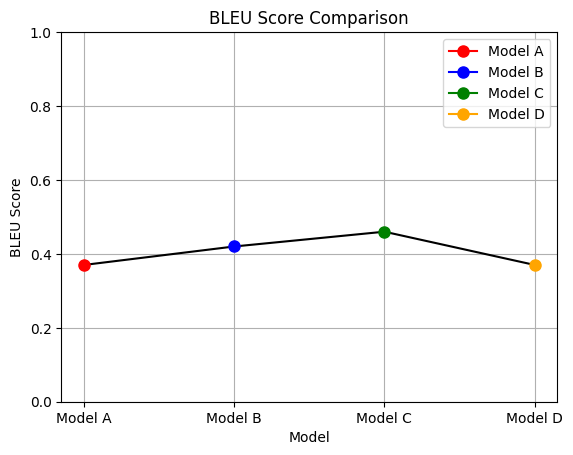

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Model': ['Model A', 'Model B', 'Model C', 'Model D'],
    'BLEU Score': [0.37, 0.42, 0.46, 0.37]
})

x = np.arange(len(df))
y = df['BLEU Score']

colors = ['red', 'blue', 'green', 'orange']

plt.figure()

plt.plot(x, y, color='black', linestyle='-')

for i, color in enumerate(colors):
    plt.plot(x[i], y[i], marker='o', color=color, label=df['Model'][i], markersize=8)

plt.xticks(x, df['Model'])
plt.title("BLEU Score Comparison")
plt.xlabel("Model")
plt.ylabel("BLEU Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()